# Structured Networks: Continuous-Time RNNs and Graph Models

Agenda:
1. Continuous-Time RNNs
2. GNN

# Continuous-Time RNNs

## CT-RNN Mathematical Formulation
Vector form (n neurons):
$$\tau \frac{d\mathbf{y}}{dt} = -\mathbf{y} + W\,\sigma(\mathbf{y}-\Theta) + \mathbf{I}(t).$$

- $\mathbf{y}(t)\in\mathbb{R}^n$: hidden state (activations)  
- $W\in\mathbb{R}^{n\times n}$: recurrent weights  
- $\sigma(\cdot)$: elementwise nonlinearity (e.g., tanh/sigmoid)  
- $\Theta$: bias/threshold vector  
- $\tau$ (scalar or per‑neuron): time constants  
- $\mathbf{I}(t)$: external input (possibly piecewise constant)

**Euler discretization (step $h$):**  
$$\mathbf{y}_{k+1} = \mathbf{y}_k + \alpha\Big(-\mathbf{y}_k + W\,\sigma(\mathbf{y}_k-\Theta) + \mathbf{I}_k\Big),\qquad \alpha=\frac{h}{\tau}.$$


## Intuition: Vanilla RNN vs. Continuous‑Time RNN

- **Vanilla RNN (discrete):** hidden state updates at discrete steps  
  $h_{t+1} = f(W_x x_{t+1} + W_h h_t + b)$

- **CTRNN (continuous):** hidden state is a function $h(t)$ that evolves according to an ODE  
  $$\tau \frac{d\mathbf{y}}{dt} = -\mathbf{y}(t) + W\,\sigma(\mathbf{y}(t)-\Theta) + \mathbf{I}(t).$$

**Intuition:** each neuron behaves like a **leaky integrator** with time constant $\tau$.  
- Large $\tau$ → slow, long‑memory dynamics.  
- Small $\tau$ → fast, reactive dynamics.  

## Analytic Solutions for CT-RNN ODEs (no numerical solver)

We consider a **scalar CTRNN** (identity nonlinearity):
$$
\tau \,\dot y(t) = -\,y(t) + u(t) \quad\Longleftrightarrow\quad 
\dot y + a\,y = b\,u(t), \qquad a=\tfrac{1}{\tau},\; b=\tfrac{1}{\tau}.
$$

This is a **first-order linear ODE**. Using the integrating factor $e^{at}$, the general solution is
$$
y(t)=e^{-at}\!\left(y_0 + \int_{t_0}^{t} e^{as}\,b\,u(s)\,ds\right).
$$

Special case:

**Constant input $u(t)=C$ (step/hold).**  
$$
y(t)=C + \big(y_0 - C\big)\,e^{-(t-t_0)/\tau}.
$$


## ODEs & Euler Integration

A first‑order ODE: $\dot{y}(t) = f(t, y(t))$.  

**Forward (explicit) Euler:**  
$$y(t+h) \approx y(t) + h\, f\!\big(t, y(t)\big).$$

For a **leaky integrator** $\tau \dot{y} = -y + u(t)$:  
$$y_{k+1} = y_k + \frac{h}{\tau}\big(-y_k + u_k\big).$$

**Stability hint (scalar case):** stable if $|1 - h/\tau| < 1 \Rightarrow 0 < h < 2\tau$.  
Too‑large $h$ ⇒ oscillations or divergence.


Test problem: τ dy/dt = −y + 1 with τ=1  ⇒  dy/dt = −y + 1

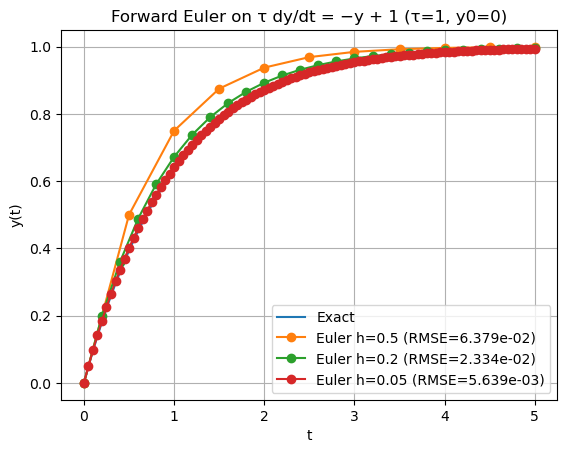

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def euler(f, y0, t0, t1, h):
    n = int(np.ceil((t1 - t0) / h))
    t = np.linspace(t0, t0 + n*h, n+1)
    y = np.empty_like(t)
    y[0] = y0
    for k in range(n):
        y[k+1] = y[k] + h * f(t[k], y[k])
    return t, y

# Test problem: τ dy/dt = −y + 1 with τ=1  ⇒  dy/dt = −y + 1
tau = 1.0
f = lambda t, y: (-y + 1.0) / tau
y_exact = lambda t, y0=0.0: 1.0 + (y0 - 1.0) * np.exp(-t)

t0, t1, y0 = 0.0, 5.0, 0.0
steps = [0.5, 0.2, 0.05]

# Plot exact and Euler with different step sizes
tt_dense = np.linspace(t0, t1, 1001)
plt.plot(tt_dense, y_exact(tt_dense, y0), label="Exact")

for h in steps:
    t, y = euler(f, y0, t0, t1, h)
    rmse = np.sqrt(np.mean((y - y_exact(t, y0))**2))
    plt.plot(t, y, marker="o", linestyle="-", label=f"Euler h={h} (RMSE={rmse:.3e})")

plt.xlabel("t"); plt.ylabel("y(t)")
plt.title("Forward Euler on τ dy/dt = −y + 1 (τ=1, y0=0)")
plt.legend(); plt.grid(True); plt.show()


## Backpropagation Through Time (BPTT) for CT-RNN

If we unroll Euler steps as a computation graph, autograd computes gradients through all timesteps (like a deep RNN).  
- Vanishing/exploding can occur for long horizons or stiff dynamics.  
- Choose $h$ and $\tau$ sensibly; consider gradient clipping.  
- Advanced: adjoint method (Neural ODEs) solves a backward‑in‑time ODE for memory efficiency.


## PyTorch: CT-RNN Layer (Euler)

We implement a CTRNN layer that performs one Euler update per time sample and applies a nonlinearity.


In [20]:
import torch
import torch.nn as nn

class ContinuousRNNLayer(nn.Module):
    """
    Continuous-time RNN layer with Euler discretization:
        y_{k+1} = y_k + (dt/tau) * ( -y_k + W_h sigma(y_k - Theta) + W_x x_k + b )
    """
    def __init__(self, input_dim, hidden_dim, tau=20.0, dt=1.0, nonlin="tanh"):
        super().__init__()
        self.hidden_dim = hidden_dim

        # Input drive: W_x x_k + b_x
        self.Wx = nn.Linear(input_dim, hidden_dim, bias=True)

        # Recurrent drive: W_h sigma(y_k - Theta) + b_h_out
        # (No bias inside the matmul; we separate the threshold Theta before sigma)
        self.Wh = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.b_h_out = nn.Parameter(torch.zeros(hidden_dim))   # optional output bias after Wh

        # Threshold (per-neuron) used as y_k - Theta before sigma
        self.Theta = nn.Parameter(torch.zeros(hidden_dim))

        # Nonlinearity sigma(.)
        if nonlin == "tanh":
            self.sigma = torch.tanh
        elif nonlin == "relu":
            self.sigma = torch.relu
        else:
            self.sigma = torch.tanh

        # Euler coefficient alpha = dt / tau
        self.register_buffer("alpha", torch.tensor(dt / tau, dtype=torch.float32))

    def forward(self, x):
        """
        x: (seq_len, batch, input_dim)
        returns: (seq_len, batch, hidden_dim)
        """
        T, B, _ = x.size()
        device = x.device
        y = torch.zeros(B, self.hidden_dim, device=device)
        outs = []

        for k in range(T):
            # W_x x_k + b_x
            input_drive = self.Wx(x[k])                       # -> R^{B x H}

            # W_h sigma(y_k - Theta) + b_h_out
            pre = y - self.Theta                              # threshold shift
            act = self.sigma(pre)                             # sigma(y_k - Theta)
            rec_drive = self.Wh(act) + self.b_h_out           # -> R^{B x H}

            # RHS: -y_k + rec_drive + input_drive
            rhs = -y + rec_drive + input_drive                # (+ b is covered by biases above)

            # Euler step: y_{k+1} = y_k + alpha * RHS
            y = y + self.alpha * rhs

            # NOTE: no extra activation here (sigma is inside RHS)
            outs.append(y)

        return torch.stack(outs, dim=0)

In [21]:
class CTRNNPredictor(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, tau=25.0, dt=1.0, nonlin="tanh"):
        super().__init__()
        self.rnn = ContinuousRNNLayer(input_dim, hidden_dim, tau=tau, dt=dt, nonlin=nonlin)
        self.readout = nn.Linear(hidden_dim, output_dim)

    def forward(self, seq):
        hseq = self.rnn(seq)              # (T, B, H)
        yseq = self.readout(hseq)         # (T, B, O)
        return yseq

## Train Example

In [25]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt


def make_sine(T=1200, cycles=12):
    time = np.linspace(0, cycles*np.pi, T, dtype=np.float32)
    data = np.sin(time).astype(np.float32)
    return time, data

def make_mixture_noise(T=1200, cycles=12, noise_std=1.0, seed=0):
    rng = np.random.default_rng(seed)
    time = np.linspace(0, cycles*np.pi, T, dtype=np.float32)
    data = (2*np.sin(time) + 1*np.cos(time)
            + 2*np.sin(10*time) + 1*np.cos(20*time)).astype(np.float32)
    data = data + rng.normal(0.0, noise_std, size=data.shape).astype(np.float32)
    return time, data

def make_trend_mixture_noise(T=1200, cycles=12, noise_std=1.0, seed=0):
    rng = np.random.default_rng(seed)
    # avoid log(0): start slightly above 0
    time = np.linspace(1e-3, cycles*np.pi, T, dtype=np.float32)
    trend = 5*np.log(time).astype(np.float32)
    seasonal = (2*np.sin(time) + 1*np.cos(time)
                + 2*np.sin(10*time) + 1*np.cos(20*time)).astype(np.float32)
    data = trend + seasonal
    data = data + rng.normal(0.0, noise_std, size=data.shape).astype(np.float32)
    return time, data

def to_supervised_1step(data: np.ndarray):
    """
    Build next-step pairs:
      x_t = data[t], y_t = data[t+1]
    Shapes match your earlier code: (T-1, 1, 1).
    """
    x = torch.tensor(data[:-1]).view(-1, 1, 1)  # (T-1, B=1, D=1)
    y = torch.tensor(data[1:]).view(-1, 1, 1)
    return x, y

In [26]:
def train_ctrnn_on_series(
    x: torch.Tensor,
    y: torch.Tensor,
    model_factory=None,
    *,
    input_dim=1, hidden_dim=16, output_dim=1,
    tau=20.0, dt=1.0, nonlin="tanh",
    lr=1e-2, epochs=100, grad_clip=1.0,
    device=None, seed=0,
    plot=True, title="CTRNN next-step prediction"
):
    """
    Train CTRNNPredictor (or any compatible factory) on a single 1-D sequence.

    Args:
      x, y: tensors of shape (T-1, B=1, D=1)
      model_factory: callable () -> model; if None, builds CTRNNPredictor(...)
      input_dim/hidden_dim/output_dim/tau/dt/nonlin: model hyperparams
      lr/epochs/grad_clip: training hyperparams
      device: 'cuda' or 'cpu' (auto if None)
      seed: torch.manual_seed
      plot: draw loss + prediction charts
    Returns:
      model, loss_hist (list of floats), pred (np.ndarray shape (T-1,))
    """
    torch.manual_seed(seed)
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")
    x = x.to(device); y = y.to(device)

    if model_factory is None:
        model = CTRNNPredictor(
            input_dim=input_dim, hidden_dim=hidden_dim,
            output_dim=output_dim, tau=tau, dt=dt, nonlin=nonlin
        )
    else:
        model = model_factory()

    model = model.to(device)
    crit = nn.MSELoss()                                
    opt  = torch.optim.Adam(model.parameters(), lr=lr)

    loss_hist = []
    for ep in range(epochs):
        opt.zero_grad()
        yhat = model(x)
        loss = crit(yhat, y)
        loss.backward()
        if grad_clip is not None:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=grad_clip)
        opt.step()
        loss_hist.append(loss.item())
        if ep % 10 == 0:
            print(f"epoch {ep:03d}  loss {loss.item():.6f}")

    # Inference without gradients (saves memory)                           
    with torch.no_grad():
        pred = model(x).squeeze(-1).squeeze(-1).cpu().numpy()

    if plot:
        # loss
        plt.figure()
        plt.plot(loss_hist)
        plt.xlabel("epoch"); plt.ylabel("MSE loss"); plt.title(f"Training loss — {title}")
        plt.show()

        # prediction vs truth
        plt.figure()
        plt.plot(np.arange(len(y.squeeze())), y.squeeze().cpu().numpy(), label="true")
        plt.plot(np.arange(len(pred)), pred, label="pred")
        plt.title(f"Next-step prediction — {title}")
        plt.legend(); plt.show()

    return model, loss_hist, pred

epoch 000  loss 0.632563
epoch 010  loss 0.123049
epoch 020  loss 0.024498
epoch 030  loss 0.006239
epoch 040  loss 0.000675
epoch 050  loss 0.001004
epoch 060  loss 0.000525
epoch 070  loss 0.000233
epoch 080  loss 0.000182
epoch 090  loss 0.000173


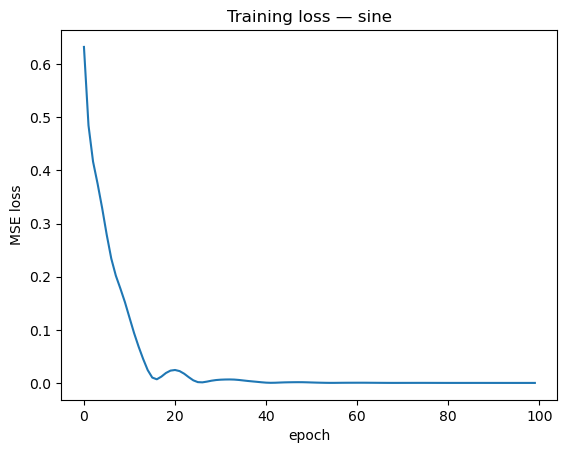

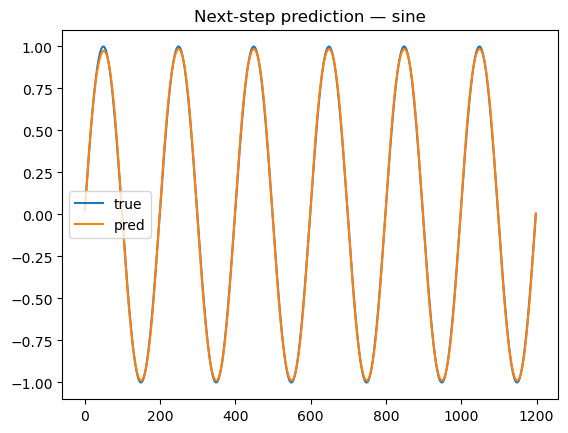

epoch 000  loss 6.087904
epoch 010  loss 3.864871
epoch 020  loss 3.636552
epoch 030  loss 3.577775
epoch 040  loss 3.523449
epoch 050  loss 3.489816
epoch 060  loss 3.447894
epoch 070  loss 3.425085
epoch 080  loss 3.462513
epoch 090  loss 3.378995
epoch 100  loss 3.307826
epoch 110  loss 3.170727
epoch 120  loss 2.990191
epoch 130  loss 2.940897
epoch 140  loss 2.803445


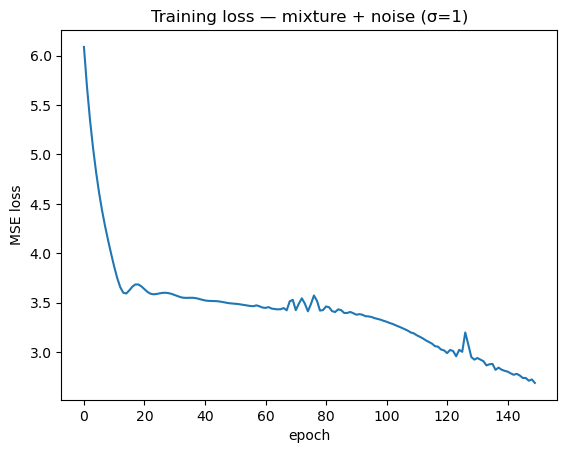

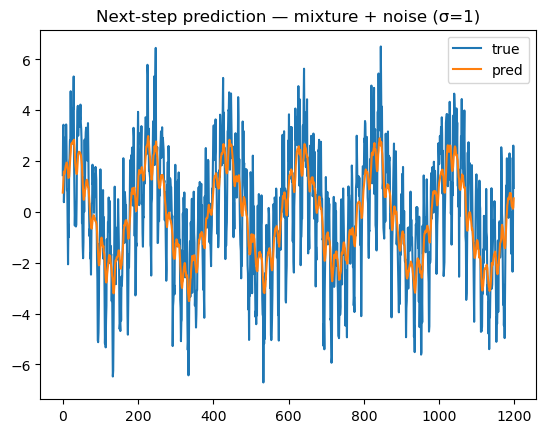

epoch 000  loss 199.935532
epoch 010  loss 5.005260
epoch 020  loss 5.058319
epoch 030  loss 5.015038
epoch 040  loss 4.619189
epoch 050  loss 4.580983
epoch 060  loss 4.490479
epoch 070  loss 4.495819
epoch 080  loss 4.366160
epoch 090  loss 4.252922
epoch 100  loss 4.177870
epoch 110  loss 4.136320
epoch 120  loss 4.196399
epoch 130  loss 3.966938
epoch 140  loss 3.928128


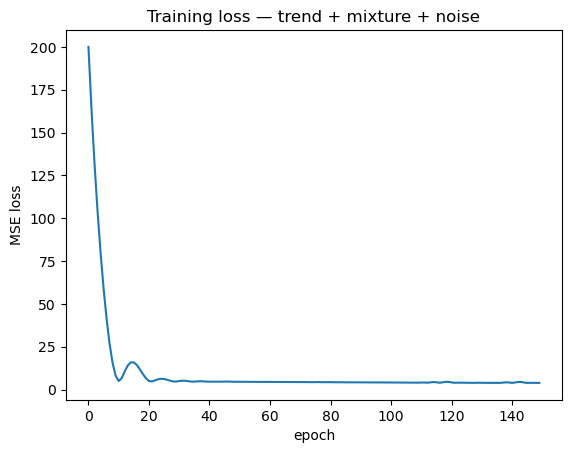

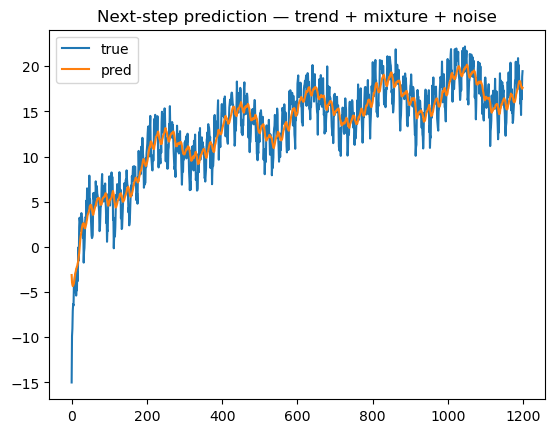

In [27]:
time, data = make_sine(T=1200, cycles=12)
x, y = to_supervised_1step(data)
_ = train_ctrnn_on_series(x, y, epochs=100, title="sine")

# 2) Multi-frequency mixture + noise
time, data = make_mixture_noise(T=1200, cycles=12, noise_std=1.0, seed=42)
x, y = to_supervised_1step(data)
_ = train_ctrnn_on_series(x, y, epochs=150, title="mixture + noise (σ=1)")

# 3) Trend + seasonal mixture + noise
time, data = make_trend_mixture_noise(T=1200, cycles=12, noise_std=1.0, seed=123)
x, y = to_supervised_1step(data)
_ = train_ctrnn_on_series(x, y, epochs=150, title="trend + mixture + noise")


## Use‑Cases & Variants

- **Irregular time series:** integrate hidden state between observations (Neural ODE / ODE‑RNN).  
- **Control & robotics:** continuous control, central pattern generators, multi‑timescale dynamics.  
- **Computational neuroscience:** rate‑based continuous dynamics.

## Related papers:
- Neural Controlled Differential Equations for
Irregular Time Series, https://proceedings.neurips.cc/paper/2020/file/4a5876b450b45371f6cfe5047ac8cd45-Paper.pdf
- EASYTPP: TOWARDS OPEN BENCHMARKING
TEMPORAL POINT PROCESSES, https://proceedings.iclr.cc/paper_files/paper/2024/file/e66233a208ef32f56df6312263239fa0-Paper-Conference.pdf
- G-CTRNN: A Trainable Low-Power Continuous-Time Neural Network for Human Activity Recognition in Healthcare Applications, https://www.mdpi.com/2076-3417/15/13/7508

# Graph Models

![](https://miro.medium.com/v2/resize:fit:1200/1*N0zapNyXm225rFR_Gk7rig.png)

## Intuition behind GNNs


* **What GNNs are for:** learning on graphs—entities (nodes) and their relationships (edges)—with a strong relational inductive bias. Typical tasks: **node classification**, **link prediction**, **graph classification**. 
* **When to use them:** whenever “who connects to whom” matters (social/citation/knowledge graphs, molecules, road networks, recommender graphs). 
* **Recommenders:** power large-scale retrieval/ranking by propagating signals over user–item graphs.
* **Knowledge graphs:** infer missing facts and types in multi-relation data (e.g., R-GCN for link prediction/entity classification).
* **Science & drug discovery:** model molecules as graphs (atoms/bonds) for property prediction, QSAR, and screening.

Many datasets are **relational** (molecules, social networks, citations, roads, knowledge graphs).  
We want predictions on nodes, edges, or whole graphs.

A **GNN** passes and aggregates information along edges to build structure‑aware representations.


At layer $k$, each node $v$ has an embedding $\mathbf{h}_v^{(k)}$. A standard **MPNN** step:

$$
\begin{aligned}
\textbf{Messages:}\quad
\mathbf{m}_v^{(k)} &= \mathrm{AGG}\Big(\{\ \phi_m(\mathbf{h}_v^{(k)},\,\mathbf{h}_u^{(k)},\,\mathbf{e}_{uv})\ :\ u\in\mathcal{N}(v)\ \}\Big),\\[4pt]
\textbf{Update:}\quad
\mathbf{h}_v^{(k+1)} &= \phi_u\big(\mathbf{h}_v^{(k)},\,\mathbf{m}_v^{(k)}\big).
\end{aligned}
$$

- $\mathbf{e}_{uv}$: optional edge features.  
- $\mathrm{AGG}$: permutation‑invariant (sum/mean/max).  
- $\phi_m,\phi_u$: small neural nets (e.g., MLPs).

After $K$ layers, $\mathbf{h}_v^{(K)}$ encodes the $K$‑hop neighborhood.


## From intuition to a concrete layer: Graph Convolutional Networks

We want each node to mix **its own** feature with **its neighbors'** features, then apply a learnable transform and a nonlinearity.

Let:

- $A\in\mathbb{R}^{n\times n}$: adjacency (no self‑loops)  
- $I$: identity  
- $\tilde A = A + I$: adjacency with self‑loops  
- $\tilde D$: degree matrix of $\tilde A$ with $\tilde D_{ii}=\sum_j \tilde A_{ij}$  
- $X\in\mathbb{R}^{n\times d_{\text{in}}}$: node features  
- $W\in\mathbb{R}^{d_{\text{in}}\times d_{\text{out}}}$: learnable weights  
- $\sigma$: nonlinearity (e.g., ReLU)

**Renormalized GCN layer**:

$$
\boxed{\; H \;=\; \sigma\!\big(\tilde D^{-1/2}\,\tilde A\,\tilde D^{-1/2}\,X\,W\big) \;}
$$

**Why this normalization?** Degree fairness, better numerical stability (controlled spectrum), and permutation invariance.


## Hand‑computable toy example (3 nodes in a line)

Graph $1\!-\!2\!-\!3$.

$$
A=\begin{bmatrix}
0&1&0\\
1&0&1\\
0&1&0
\end{bmatrix},\qquad
\tilde A = A + I = 
\begin{bmatrix}
1&1&0\\
1&1&1\\
0&1&1
\end{bmatrix}.
$$

Degrees of $\tilde A$: $\tilde d=[2,3,2]$, so

$$
\tilde D^{-1/2}=\mathrm{diag}\!\Big(\tfrac{1}{\sqrt2},\,\tfrac{1}{\sqrt3},\,\tfrac{1}{\sqrt2}\Big).
$$

Aggregator (symmetric normalization):

$$
S=\tilde D^{-1/2}\,\tilde A\,\tilde D^{-1/2}=
\begin{bmatrix}
0.5 & 0.408248 & 0 \\
0.408248 & 0.333333 & 0.408248 \\
0 & 0.408248 & 0.5
\end{bmatrix}.
$$

Scalar features $X=\begin{bmatrix}1\\2\\3\end{bmatrix}$ and scalar weight $W=2$, identity activation:

$$
H = S X W = 2\cdot S X =
\begin{bmatrix}
2.632992\\
4.599316\\
4.632992
\end{bmatrix}.
$$


In [1]:

# Numeric verification of the toy GCN layer
import torch

A = torch.tensor([[0.,1.,0.],
                  [1.,0.,1.],
                  [0.,1.,0.]])
I = torch.eye(3)
A_tilde = A + I
deg = A_tilde.sum(dim=1)
D_inv_sqrt = torch.diag(torch.pow(deg, -0.5))
S = D_inv_sqrt @ A_tilde @ D_inv_sqrt

X = torch.tensor([[1.],[2.],[3.]])
W = torch.tensor([[2.]])  # 1 -> 1

H = S @ X @ W  # one GCN layer without nonlinearity
print('S=\n', S)
print('H=\n', H)

S=
 tensor([[0.5000, 0.4082, 0.0000],
        [0.4082, 0.3333, 0.4082],
        [0.0000, 0.4082, 0.5000]])
H=
 tensor([[2.6330],
        [4.5993],
        [4.6330]])


In [3]:
# pip install torch-geometric

## Cora dataset example

Each paper in the Cora dataset is described by a binary word vector, which serves as the feature set for the dataset. The presence (1) or absence (0) of each word from a dictionary of 1,433 unique words is recorded in this vector. This high-dimensional feature space captures the content of each paper, enabling detailed analysis and classification.


The labels in the Cora dataset correspond to the seven classes of machine learning topics:
- Case Based
- Genetic Algorithms
- Neural Networks
- Probabilistic Methods
- Reinforcement Learning
- Rule Learning
- Theory

In [2]:
import torch
from torch_geometric.datasets import Planetoid
from torch_geometric.utils import degree

dataset = Planetoid(root='data/Planetoid', name='Cora')  # standard Planetoid split: 140/500/1000
data = dataset[0]

# --- overall basics (from the loaded graph) ---
num_nodes  = data.num_nodes
num_edges  = data.edge_index.size(1)            # directed edges in COO (Cora is undirected -> counted both ways)
num_feats  = data.num_node_features
num_classes= dataset.num_classes

print(f"Nodes: {num_nodes} | Edges (directed in edge_index): {num_edges} "
      f"| Features per node: {num_feats} | Classes: {num_classes}")

# --- split sizes (Planetoid fixed masks) ---
train_n = int(data.train_mask.sum())
val_n   = int(data.val_mask.sum())
test_n  = int(data.test_mask.sum())
print(f"Split sizes -> train: {train_n}, val: {val_n}, test: {test_n}")
# Planetoid’s standard split is 140/500/1000.

# --- degrees ---
deg = degree(data.edge_index[0], num_nodes=num_nodes)  # degree per node (counts both directions on undirected graphs)

# (A) degree of test nodes w.r.t. the FULL graph (incident edges to anywhere)
test_deg = deg[data.test_mask]
print(f"Test nodes (incident to any node) -> mean degree: {float(test_deg.mean()):.3f}, "
      f"median: {float(test_deg.median()):.3f}")

# (B) degree INSIDE the test-induced subgraph (edges with both endpoints in test)
src, dst = data.edge_index
both_test = data.test_mask[src] & data.test_mask[dst]
ei_test = data.edge_index[:, both_test]               # keep only test<->test edges (still directed)
deg_test_sub = degree(ei_test[0], num_nodes=num_nodes)[data.test_mask]
print(f"Test-induced subgraph -> mean degree: {float(deg_test_sub.mean()):.3f}, "
      f"median: {float(deg_test_sub.median()):.3f}")

# --- label distribution per split ---
def split_counts(mask):
    y = data.y[mask]
    binc = torch.bincount(y, minlength=num_classes)
    return binc.tolist()

print("Label counts -> train:", split_counts(data.train_mask))
print("Label counts -> val:  ", split_counts(data.val_mask))
print("Label counts -> test: ", split_counts(data.test_mask))

# --- peek at one row (a test node) ---
test_idx = torch.nonzero(data.test_mask, as_tuple=True)[0][0].item()
x_row = data.x[test_idx]            # feature vector (BoW-style for Cora)
nz_idx = torch.nonzero(x_row, as_tuple=True)[0]
print(f"Example test node index: {test_idx}")
print(f"Non-zero features count: {nz_idx.numel()} (out of {num_feats})")
print(f"First 20 non-zero feature indices: {nz_idx[:20].tolist()}")
print(f"Label (class id): {int(data.y[test_idx])}")

Nodes: 2708 | Edges (directed in edge_index): 10556 | Features per node: 1433 | Classes: 7
Split sizes -> train: 140, val: 500, test: 1000
Test nodes (incident to any node) -> mean degree: 3.712, median: 3.000
Test-induced subgraph -> mean degree: 1.306, median: 1.000
Label counts -> train: [20, 20, 20, 20, 20, 20, 20]
Label counts -> val:   [61, 36, 78, 158, 81, 57, 29]
Label counts -> test:  [130, 91, 144, 319, 149, 103, 64]
Example test node index: 1708
Non-zero features count: 20 (out of 1433)
First 20 non-zero feature indices: [7, 41, 65, 192, 203, 225, 230, 233, 550, 584, 619, 917, 1172, 1174, 1177, 1181, 1263, 1267, 1340, 1351]
Label (class id): 3


In [4]:
import os
import random
import numpy as np
import torch
import torch.nn.functional as F
from torch import nn
from torch_geometric.datasets import Planetoid
from torch_geometric.transforms import NormalizeFeatures
from torch_geometric.nn import GCNConv

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [5]:
data = dataset[0]  # single-graph dataset
num_features = dataset.num_features
num_classes = dataset.num_classes

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
data = data.to(device)

In [6]:
class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim, cached=True, normalize=True)
        self.conv2 = GCNConv(hidden_dim, out_dim, cached=True, normalize=True)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.relu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

model = GCN(num_features, hidden_dim=64, out_dim=num_classes, dropout=0.5).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)  # classic GCN settings

In [7]:
@torch.no_grad()
def evaluate():
    model.eval()
    logits = model(data.x, data.edge_index)
    # Split by masks from Planetoid's standard split
    def acc(mask):
        pred = logits[mask].argmax(dim=-1)
        y = data.y[mask]
        return (pred == y).float().mean().item()
    loss_val = F.cross_entropy(logits[data.val_mask], data.y[data.val_mask]).item()
    return {
        "val_loss": loss_val,
        "train_acc": acc(data.train_mask),
        "val_acc": acc(data.val_mask),
        "test_acc": acc(data.test_mask),
    }

The key trick is to compute the loss from the mask-derived node indices while the GCN still runs on the full graph for each forward pass (standard for node classification on single-graph benchmarks).

In [8]:
def train_one_epoch():
    model.train()
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

In [9]:
best_state = None
best_val_acc = -1.0
patience = 200
pat_ctr = 0
max_epochs = 2000

for epoch in range(1, max_epochs + 1):
    loss = train_one_epoch()
    metrics = evaluate()
    val_acc = metrics["val_acc"]

    improved = val_acc > best_val_acc
    if improved:
        best_val_acc = val_acc
        best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
        pat_ctr = 0
    else:
        pat_ctr += 1

    if epoch % 50 == 0 or improved:
        print(f"Epoch {epoch:04d} | loss {loss:.4f} | "
              f"train {metrics['train_acc']*100:.2f}% | "
              f"val {metrics['val_acc']*100:.2f}% | "
              f"test {metrics['test_acc']*100:.2f}%")

    if pat_ctr >= patience:
        print(f"Early stopping at epoch {epoch} (best val_acc={best_val_acc*100:.2f}%).")
        break

# ---------- Load best and report final test ----------
if best_state is not None:
    model.load_state_dict(best_state)

final = evaluate()
print("\n== Final (best-by-val) ==")
print(f"Train Acc: {final['train_acc']*100:.2f}%")
print(f"Val   Acc: {final['val_acc']*100:.2f}%")
print(f"Test  Acc: {final['test_acc']*100:.2f}%")

Epoch 0001 | loss 1.9490 | train 87.86% | val 54.40% | test 55.30%
Epoch 0002 | loss 1.6999 | train 96.43% | val 66.20% | test 68.40%
Epoch 0003 | loss 1.4267 | train 98.57% | val 71.20% | test 73.10%
Epoch 0004 | loss 1.1016 | train 98.57% | val 75.40% | test 75.60%
Epoch 0005 | loss 0.8400 | train 98.57% | val 77.40% | test 78.00%
Epoch 0006 | loss 0.6359 | train 98.57% | val 77.60% | test 79.50%
Epoch 0007 | loss 0.4595 | train 98.57% | val 78.80% | test 80.30%
Epoch 0008 | loss 0.3374 | train 98.57% | val 79.20% | test 80.70%
Epoch 0050 | loss 0.0095 | train 100.00% | val 77.80% | test 79.70%
Epoch 0100 | loss 0.0158 | train 100.00% | val 77.80% | test 80.70%
Epoch 0150 | loss 0.0106 | train 100.00% | val 76.20% | test 80.50%
Epoch 0200 | loss 0.0086 | train 100.00% | val 76.00% | test 80.40%
Early stopping at epoch 208 (best val_acc=79.20%).

== Final (best-by-val) ==
Train Acc: 98.57%
Val   Acc: 79.20%
Test  Acc: 80.70%


Check comparison with tabular MLP e.g. [here](https://github.com/stsfaroz/Graph-Convolutional-Networks-with-Cora-Dataset/blob/main/GCNN.ipynb)

In [10]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE

def get_module_by_name(model, dotted_name: str):
    """Fetch nested modules like 'conv1' or 'encoder.block1.norm'."""
    mod = model
    for attr in dotted_name.split('.'):
        mod = getattr(mod, attr)
    return mod

def capture_activations(model, layer_name: str, forward_input):
    """
    Register a forward hook on `layer_name` and run one forward pass to collect activations.
    forward_input should be a tuple of (x, edge_index, *args) appropriate for your model.
    """
    acts = {}

    def hook_fn(module, inp, out):
        # out is the tensor we want (shape: [num_nodes, hidden_dim] for GCNConv)
        acts['out'] = out.detach().cpu()

    layer = get_module_by_name(model, layer_name)
    handle = layer.register_forward_hook(hook_fn)

    model.eval()
    with torch.no_grad():
        _ = model(*forward_input)

    handle.remove()
    return acts['out']  # torch.Tensor [N, D]

def reduce_2d(emb, method="tsne", random_state=42, **kwargs):
    """
    emb: torch.Tensor or np.ndarray [N, D]
    method: 'tsne' or 'umap'
    kwargs: extra params passed to reducer (e.g., perplexity=30 for t-SNE)
    """
    X = emb.numpy() if isinstance(emb, torch.Tensor) else emb
    if method == "tsne":
        return TSNE(n_components=2, random_state=random_state, **kwargs).fit_transform(X)
    elif method == "umap":
        import umap 
        return umap.UMAP(n_components=2, random_state=random_state, **kwargs).fit_transform(X)
    else:
        raise ValueError("method must be 'tsne' or 'umap'")

def plot_embedding_2d(Z, labels, title="Hidden representation (2-D)", num_classes=None):
    """
    Z: [N, 2] embedding
    labels: 1-D tensor/ndarray of class ids (N,)
    """
    y = labels.cpu().numpy() if hasattr(labels, "cpu") else np.asarray(labels)
    if num_classes is None:
        num_classes = int(y.max()) + 1

    plt.figure(figsize=(8, 8))
    for cl in range(num_classes):
        idx = (y == cl)
        plt.scatter(Z[idx, 0], Z[idx, 1], s=12, alpha=0.8, label=str(cl))
    plt.legend(title="Class")
    plt.title(title)
    plt.xlabel("dim 1")
    plt.ylabel("dim 2")
    plt.tight_layout()
    plt.show()

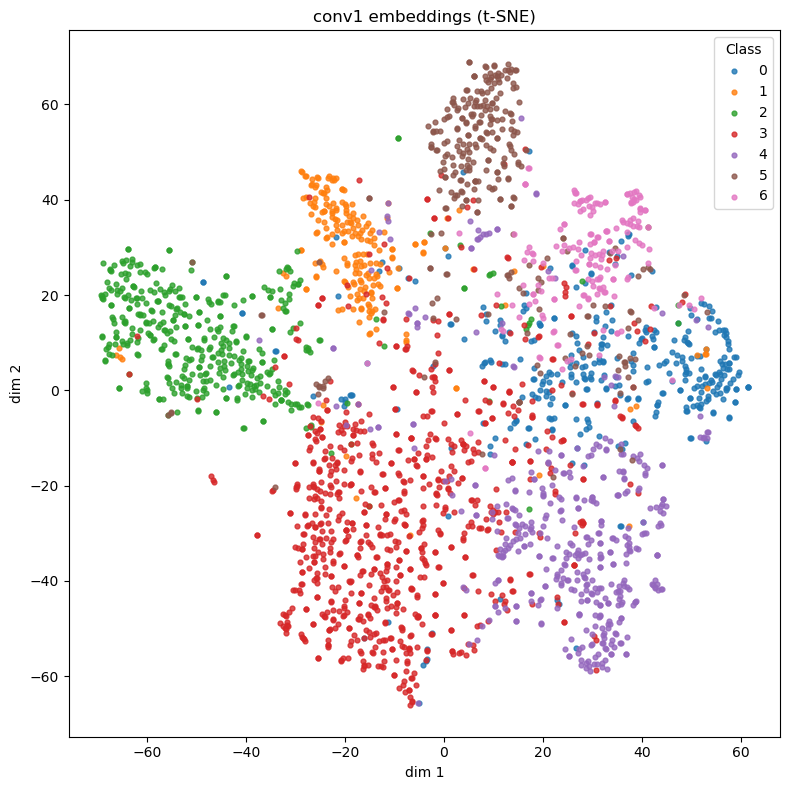

In [13]:
layer_name = "conv1"
emb = capture_activations(model, layer_name, forward_input=(data.x, data.edge_index))
emb = torch.clamp(emb, min=0)

Z = reduce_2d(emb, method="tsne", perplexity=30, init="pca")
plot_embedding_2d(Z, labels=data.y, title=f"{layer_name} embeddings (t-SNE)")

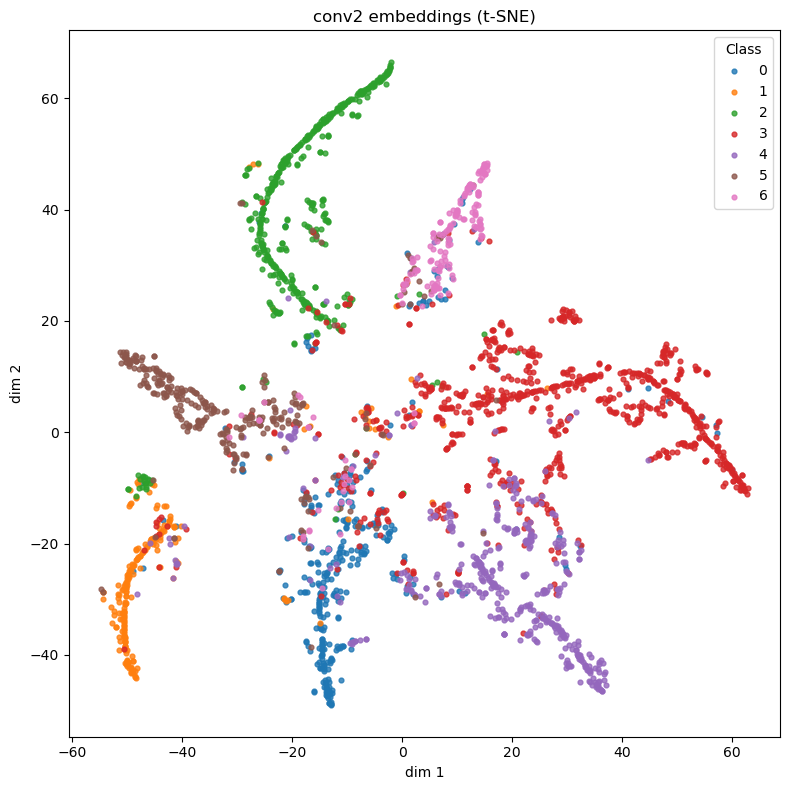

In [15]:
layer_name = "conv2"
emb = capture_activations(model, layer_name, forward_input=(data.x, data.edge_index))
emb = torch.clamp(emb, min=0)

Z = reduce_2d(emb, method="tsne", perplexity=30, init="pca")
plot_embedding_2d(Z, labels=data.y, title=f"{layer_name} embeddings (t-SNE)")